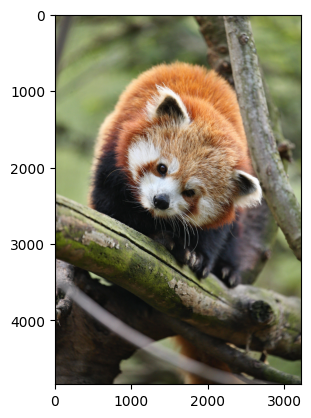

In [1]:
# 데이터 증강
# : 기존 학습 데이터의 양과 다양성을 인위적으로 늘려 딥러닝/머신러닝 모델의
# 과적합(Overfitting)을 방지하고 일반화 성능을 향상시키는 기법입니다.
# 적은 데이터를 활용해 고품질 학습 데이터셋을 구축하여 데이터 수집 비용을 절감하는 핵심 기술

# pip install opencv-python <= colab은 이미 설치됨

import cv2
import matplotlib.pyplot as plt
import numpy as np
from tensorflow.keras.preprocessing.image import ImageDataGenerator

image = cv2.cvtColor(cv2.imread('test_aug.jpg'), cv2.COLOR_BGR2RGB)
plt.imshow(image)

In [6]:
def show_aug_func(image, generator, n_image = 4):
  image_batch = np.expand_dims(image, axis=0)
  generator.fit(image_batch)
  # 메모리에 로딩된 이미지 배열을 ImageDataGenerator에 넣어 증강된 이미지를 배치 단위로 생성
  data_gen_iter = generator.flow(image_batch)
  fig, axs = plt.subplots(1, n_image, figsize=(24, 8))

  for i in range(n_image):
    aug_image_batch = next(data_gen_iter)
    aug_image = np.squeeze(aug_image_batch)  # 크기가 1인 축  제거해 차원 축소
    aug_image = aug_image.astype('int')
    axs[i].imshow(aug_image)
  plt.show()

# 좌우반전
data_generator = ImageDataGenerator(horizontal_flip=True)
show_aug_func(image, data_generator, n_image=4)

# 상하 반전
data_generator = ImageDataGenerator(vertical_flip=True)
show_aug_func(image, data_generator, n_image=4)

# 회전
data_generator = ImageDataGenerator(rotation_range=45)
show_aug_func(image, data_generator, n_image=4)

# 좌우로 랜덤하게 이동
data_generator = ImageDataGenerator(width_shift_range=0.3, fill_mode = 'nearest')
show_aug_func(image, data_generator, n_image=4)

# 색상 채널 값 랜덤하게 변경
data_generator = ImageDataGenerator(channel_shift_range=150)
show_aug_func(image, data_generator, n_image=4)

Output hidden; open in https://colab.research.google.com to view.

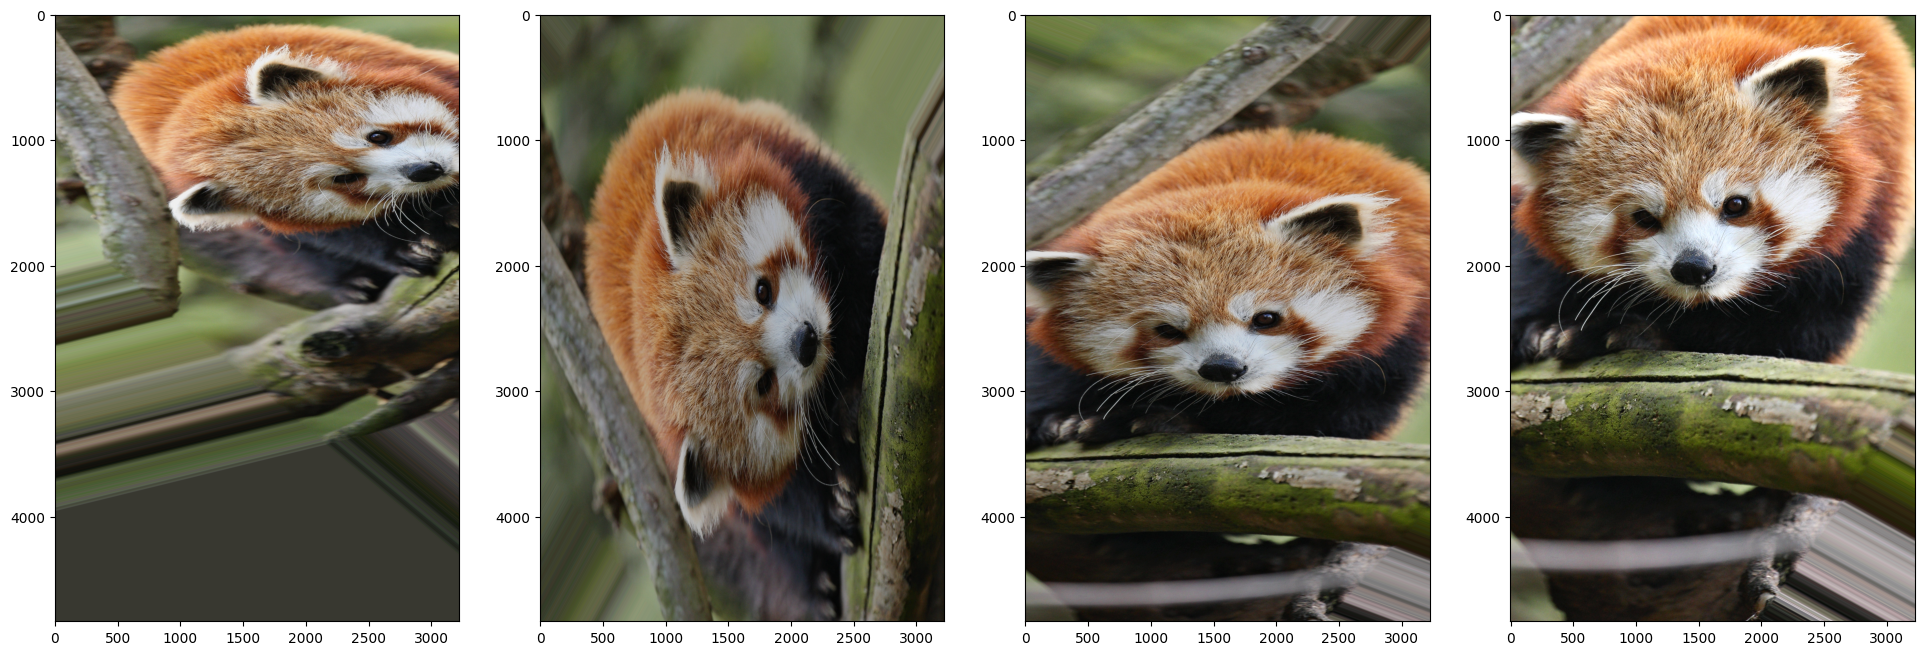

In [7]:
data_gen = ImageDataGenerator(
    rotation_range=50,
    width_shift_range=0.3,
    brightness_range=(0.7, 1.3),
    horizontal_flip=True,
    vertical_flip=True,
    zoom_range = 0.5
)
show_aug_func(image, data_gen, n_image=4)